# EXFOR-to-ENDF Angular Distribution Pipeline — Full Methodology

This notebook documents **every key decision** in the pipeline that converts experimental angular distributions (EXFOR) into evaluated Legendre coefficients with covariance matrices (ENDF MF4/MF34). Each section corresponds to a pipeline phase and explains the *why* behind each choice.

## Pipeline overview

```
Phase 1: Data selection & weighting
  ├─ Energy binning (TOF resolution)
  ├─ Overlap weights (Gaussian CDF per experiment)
  ├─ Study-level sublinear weighting (γ-power + dominance cap)
  ├─ Uncertainty floor
  └─ Angular quality gate (min points + 3-band coverage)

Phase 2: Nominal fitting
  ├─ Weighted ridge regression (Legendre basis)
  ├─ Degree selection (AICc) + model averaging
  ├─ Angular-band discrepancy (τ_F, τ_M, τ_B)
  ├─ IRLS refit of nominal with inflated σ_eff
  ├─ Tau smoothing & prior floor across energy
  ├─ Nominal σ_eff reconstruction from frozen τ
  ├─ N_eff diagnostic (point-level)
  └─ MC order cap from angular support

Phase 3: Monte Carlo sampling
  ├─ Per-experiment normalization perturbation (σ_norm)
  ├─ Degree sampling from AICc weights
  ├─ Pointwise noise with σ_eff
  ├─ FREEZE_C0 (shape-only refit)
  ├─ Positivity projection (Layer 2: SLSQP)
  └─ ENDF normalization (a_l)

Phase 4: Correlation methods (three options)
  ├─ Gaussian parametric (exponential decay)
  ├─ Kernel-weight MC (shared perturbations → natural correlations)
  └─ Hybrid blend (α from N_eff,kw)
      ├─ Two-pass: per-bin variance + KW correlations
      └─ Cholesky resampling from combined covariance

Phase 5: Covariance post-processing
  ├─ Near-zero regularization (SNR-based)
  ├─ High rel-std interpolation
  ├─ Absent-order / dip / spike smoothing
  ├─ Gaussian diagonal smoothing
  ├─ Order-dependent hard caps
  └─ PSD projection (eigenvalue clipping)
```

---

# Phase 1: Data Selection & Weighting

## 1.1 Energy binning from TOF resolution

The ENDF energy grid is taken from a reference file (e.g. JEFF-4.0). For each grid energy $E$, the **time-of-flight (TOF) energy resolution** determines the bin width:

$$\sigma_E = E \sqrt{\left(\frac{\Delta t}{t}\right)^2 + \varepsilon^2}, \qquad t = \frac{L}{\sqrt{2E / m_n}}$$

where $L$ is the flight path (default 27.037 m), $\Delta t$ the time resolution (default 5.0 ns), $m_n$ the neutron mass, and $\varepsilon = 10^{-4}$ a numerical floor. The bin boundaries are midpoints between consecutive grid energies.

**Why TOF resolution?** The bin width should match the energy resolution of a typical neutron scattering facility. If the bin is narrower than the resolution, the data within it would be indistinguishable from neighboring bins. If wider, we lose information. Using $\sigma_E$ from the facility's TOF parameters gives a physically motivated bin width.

## 1.2 Overlap weights — which experiments "see" each bin?

Each EXFOR experiment measures angular distributions at discrete energies $E_k$ with its own energy resolution $\sigma_{E,k}$ (from its TOF parameters if available, otherwise the bin's default $\sigma_E$). The **overlap weight** is the probability that the measurement falls within the bin:

$$w_k = \Phi\!\left(\frac{E_{\text{high}} - E_k}{\sigma_{E,k}}\right) - \Phi\!\left(\frac{E_{\text{low}} - E_k}{\sigma_{E,k}}\right)$$

where $\Phi$ is the standard normal CDF. This is computed in `compute_overlap_weight()`.

**Key behaviours:**
- Experiment energy well inside the bin → $w \approx 1$
- Experiment energy far outside → $w \approx 0$
- Poor resolution (large $\sigma_{E,k}$) → weight smears across multiple bins
- Good resolution (small $\sigma_{E,k}$) → weight concentrated in the correct bin

**Filtering:** Only datasets with $w_k \geq w_{\min}$ (default $10^{-3}$) are kept.

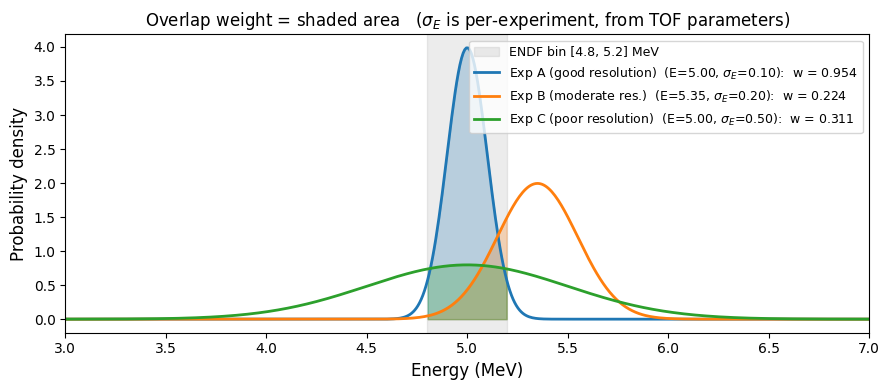

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- Visualise overlap weights for a single bin ---
bin_low, bin_high = 4.8, 5.2  # ENDF bin [4.8, 5.2] MeV

# Each experiment has its OWN σ_E (from its TOF parameters: flight path + time resolution).
experiments = [
    {"name": "Exp A (good resolution)",  "E": 5.0,  "sigma_E": 0.10, "color": "C0"},
    {"name": "Exp B (moderate res.)",    "E": 5.35, "sigma_E": 0.20, "color": "C1"},
    {"name": "Exp C (poor resolution)",  "E": 5.0,  "sigma_E": 0.50, "color": "C2"},
]

fig, ax = plt.subplots(figsize=(9, 4))
E_range = np.linspace(3.0, 7.0, 500)

ax.axvspan(bin_low, bin_high, alpha=0.15, color="grey", label=f"ENDF bin [{bin_low}, {bin_high}] MeV")

for exp in experiments:
    pdf = norm.pdf(E_range, exp["E"], exp["sigma_E"])
    w = norm.cdf(bin_high, exp["E"], exp["sigma_E"]) - norm.cdf(bin_low, exp["E"], exp["sigma_E"])
    ax.plot(E_range, pdf, color=exp["color"], lw=2,
            label=f'{exp["name"]}  (E={exp["E"]:.2f}, $\\sigma_E$={exp["sigma_E"]:.2f}):  w = {w:.3f}')
    ax.fill_between(E_range, pdf, where=(E_range >= bin_low) & (E_range <= bin_high),
                     alpha=0.25, color=exp["color"])

ax.set_xlabel("Energy (MeV)", fontsize=12)
ax.set_ylabel("Probability density", fontsize=12)
ax.set_title("Overlap weight = shaded area   ($\\sigma_E$ is per-experiment, from TOF parameters)", fontsize=12)
ax.legend(fontsize=9, loc="upper right")
ax.set_xlim(3.0, 7.0)
plt.tight_layout()
plt.show()

## 1.3 Experiment-level weight renormalization

### The problem with raw "all datasets" weights

A dense-grid experiment (e.g. Cierjacks, with measurements every 0.01 MeV) can have ~20 energies overlapping a single bin, each with $w_k > 0$. Their raw sum might be $\sum w_k \approx 5$–$10$, while a sparse experiment with one perfectly-centered measurement gets $w \approx 0.9$. This inflates the dense experiment's influence disproportionately — 20 nearby energies from the same experiment are **not** 20× more informative than 1 well-centered measurement.

### The solution: renormalize per experiment

After collecting all datasets with $w_k \geq w_{\min}$ for a bin, we group by experiment and scale:

$$w_k^{\text{norm}} = w_k \times \frac{\max_j(w_j)}{\sum_j w_j} \qquad \text{(sum over datasets in the same experiment)}$$

This ensures:
- **Each experiment's total weight = its best single overlap** (same influence as closest-only dedup would give)
- **All angular data points are still used** in the Legendre fit (richer angular coverage)
- **Relative weights within an experiment are preserved** (better-centered energies contribute more)

| Experiment | Raw weights | Sum | Max | Scale | Normalized sum |
|---|---|---|---|---|---|
| Sparse (1 dataset) | [0.90] | 0.90 | 0.90 | 1.000 | 0.90 |
| Dense (5 datasets) | [0.9, 0.7, 0.5, 0.3, 0.1] | 2.50 | 0.90 | 0.360 | 0.90 |

Both experiments now have the same total influence (0.90), but the dense one contributes 5× more angular data points to the fit.

## 1.4 Study-level sublinear weighting ($g_k$)

Within a single energy bin, experiments contribute different numbers of angular data points. A study with 40 angular points would otherwise dominate one with 8 points, purely because of point count. The pipeline applies **sublinear weighting** controlled by $\gamma$ (`WEIGHT_GAMMA`).

### Per-study budget vs per-point weight

The parameter $\gamma$ controls how a study's total "budget" scales with its number of angular points $n_j$. The **per-study weight budget** is:

$$W_j = n_j^\gamma$$

Since this budget is distributed across all $n_j$ angular points of study $j$, the **per-point weight** assigned to each data point $i$ belonging to study $j$ is:

$$g_i = \frac{W_j}{n_j} = n_j^{\gamma - 1}$$

This $g_i$ is the value stored as `kernel_weight` in the pipeline and passed as `external_weights` to the fitting function. It enters the fitting objective as a multiplicative factor on each data point's contribution (see Section 2.1).

| $\gamma$ | Per-study budget $W_j$ | Per-point weight $g_i$ | Effect |
|---|---|---|---|
| 0 | $1$ (constant) | $1/n_j$ | Equal weight per study — all experiments count equally |
| 0.5 | $\sqrt{n_j}$ | $1/\sqrt{n_j}$ | **Default** — compromise between study and point equality |
| 1 | $n_j$ | $1$ (uniform) | Equal weight per point — large experiments dominate |

**Example** ($\gamma = 0.5$): Study A has $n_A = 36$ points, Study B has $n_B = 4$ points:
- Study A: per-point $g_i = 36^{-0.5} = 1/6$, total budget $= 36 \times (1/6) = 6$
- Study B: per-point $g_i = 4^{-0.5} = 1/2$, total budget $= 4 \times (1/2) = 2$
- Study A gets 3× the total influence of Study B (not 9× as with uniform weighting)

### Dominance cap

After computing $g_i$ values, a **dominance cap** (`MAX_EXP_WEIGHT_FRAC_BIN = 0.50`) prevents any single experiment from exceeding 50% of the total weight. If an experiment exceeds this fraction, its weight is clipped and the remainder redistributed proportionally among the other experiments.

## 1.5 Uncertainty floor

Unrealistically small reported uncertainties (e.g. <1%) can dominate the fit. The pipeline applies a floor:

- **Strategy `bin_median`** (default): replace uncertainties below `MIN_RELATIVE_UNCERTAINTY` (5%) with the bin's median relative uncertainty
- **Strategy `fixed`**: simple hard floor at `MIN_RELATIVE_UNCERTAINTY`

This prevents a single high-precision but potentially biased measurement from pulling the fit.

## 1.6 Angular quality gate

Before fitting, each energy bin is checked for **minimum angular coverage quality**. The gate requires:

1. **Minimum number of angular points** (`MIN_ANGULAR_POINTS = 4`): at least 4 data points in the bin
2. **Minimum band coverage** (`MIN_BANDS_COVERED = 3`): data must be present in all three angular bands (Forward: $\mu > 0.5$, Mid: $|\mu| \leq 0.5$, Backward: $\mu < -0.5$)

If the bin fails the quality gate, the pipeline attempts **iterative bin expansion**: it widens the energy bin boundaries by incorporating data from neighboring bins (up to `MAX_BIN_EXPANSION = 2` steps, i.e. ±1 then ±2 adjacent bins). At each expansion step, the quality check is re-evaluated.

- If expansion succeeds: the expanded dataset is used (with a log noting the expansion level)
- If expansion fails after all attempts: the bin is marked as "no data" and its coefficients will be **interpolated** from neighboring bins that passed

**Why this gate?** A Legendre fit with data covering only forward angles (e.g. only $\mu > 0.5$) cannot reliably constrain backward-angle behavior. Without the gate, the fit would extrapolate wildly into uncovered angular regions, producing unphysical distributions. By requiring 3-band coverage, we ensure the fit is constrained across the full angular range.

---

# Phase 2: Nominal Fitting

## 2.1 Weighted ridge regression — objective function

At each energy bin, we fit Legendre polynomials to the collected angular distribution data. The model is:

$$\sigma(\mu) = \sum_{l=0}^{L} c_l P_l(\mu)$$

where $\mu = \cos\theta_{\text{CM}}$ and $P_l$ are Legendre polynomials.

### What we minimize

The fit minimizes a penalized weighted least-squares objective:

$$\mathcal{L}(\mathbf{c}) = \sum_{i=1}^{n} \frac{g_i}{\sigma_{\text{eff},i}^2} \left(y_i - \sum_{l=0}^{L} c_l P_l(\mu_i)\right)^2 + \lambda \sum_{l=1}^{L} l^p \, c_l^2$$

The **combined weight** per data point is $w_i = g_i / \sigma_{\text{eff},i}^2$, where:
- $g_i$ is the per-point study-level weight from Phase 1 (Section 1.4): $g_i = n_j^{\gamma-1}$ for point $i$ belonging to study $j$
- $\sigma_{\text{eff},i}$ is the effective uncertainty (either the original $\sigma_i$, the Birge-scaled $\sigma_i$, or the band-inflated $\sqrt{\sigma_i^2 + \tau_b^2}$ — see Section 2.3)

The ridge penalty only applies to $l \geq 1$ (no penalty on $c_0$, the angle-integrated cross section) with power $p = 4$ by default, so the penalty grows as $l^4$.

### Matrix form and normal equations

Defining the **Legendre design matrix** $V_{il} = P_l(\mu_i)$, the diagonal weight matrix $W = \text{diag}(w_1, \ldots, w_n)$, and the ridge penalty matrix $R = \text{diag}(0, 1^p, 2^p, \ldots, L^p)$, the objective becomes:

$$\mathcal{L}(\mathbf{c}) = (\mathbf{y} - V\mathbf{c})^T W (\mathbf{y} - V\mathbf{c}) + \lambda \, \mathbf{c}^T R \, \mathbf{c}$$

Setting $\nabla_\mathbf{c} \mathcal{L} = 0$ yields the **normal equations**:

$$(V^T W V + \lambda R) \, \mathbf{c} = V^T W \, \mathbf{y}$$

which is the system $M \mathbf{c} = \mathbf{b}$ solved by `np.linalg.solve`. In practice, the code works with the "square-root weight" form: $\tilde{V} = \sqrt{W}\,V$ and $\tilde{\mathbf{y}} = \sqrt{W}\,\mathbf{y}$, so that $M = \tilde{V}^T \tilde{V} + \lambda R$.

### Fixed-coefficient mode

When `FREEZE_C0 = True` (shape-only refit), $c_0$ is held at its nominal value and subtracted from $\mathbf{y}$. The system is then solved for $c_1, \ldots, c_L$ only, using a reduced design matrix with the $l=0$ column removed. Similarly, `max_sample_order` freezes coefficients above a given order during MC sampling.

**Why ridge with power $p=4$?** Pure least-squares with high-order Legendre polynomials is ill-conditioned — small perturbations in data cause wild oscillations in high-$l$ coefficients. The $l^4$ penalty provides strong regularization for $l \geq 3$ while barely affecting $l=0,1$. This keeps the fit smooth without sacrificing the dominant low-order structure.

**Degrees of freedom:** The effective degrees of freedom are computed from the hat matrix trace: $\text{df}_{\text{eff}} = \text{tr}(H)$ where $H = \tilde{V} \, M^{-1} \, \tilde{V}^T$. This is more accurate than the naive $L+1$ when ridge is active, because the ridge penalty effectively "consumes" fewer than one full degree of freedom per penalized coefficient.

## 2.2 Degree selection (AICc) and model averaging

The maximum Legendre degree $L$ is not fixed a priori. The pipeline scans $L = 0, 1, \ldots, L_{\max}$ (capped by data availability) and selects the best degree using the **corrected Akaike Information Criterion (AICc)**:

$$\text{AICc} = \chi^2 + 2\,k + \frac{2\,k(k+1)}{n - k - 1}$$

where $\chi^2 = \sum_i w_i (y_i - \hat{y}_i)^2$ is the weighted sum of squared residuals and $k = \text{df}_{\text{eff}}$ is the effective number of parameters. AICc balances goodness-of-fit against model complexity, with a finite-sample correction that penalizes overfitting more severely when $n$ is small relative to $L$.

**Model averaging** (when `USE_MODEL_AVERAGING = True`): instead of committing to a single $L$, the pipeline computes AICc weights:

$$w_d \propto \exp\!\left(-\tfrac{1}{2}\,\Delta\text{AICc}_d\right), \qquad \Delta\text{AICc}_d = \text{AICc}_d - \min_d \text{AICc}_d$$

Degrees with $w_d > 1\%$ and $d \geq$ `MIN_DEGREE_FOR_AVERAGING` are retained. During MC sampling (Phase 3), each sample **draws its degree from this distribution**, so the ensemble of samples reflects structural uncertainty about the true polynomial order — not just parameter uncertainty at a fixed order.

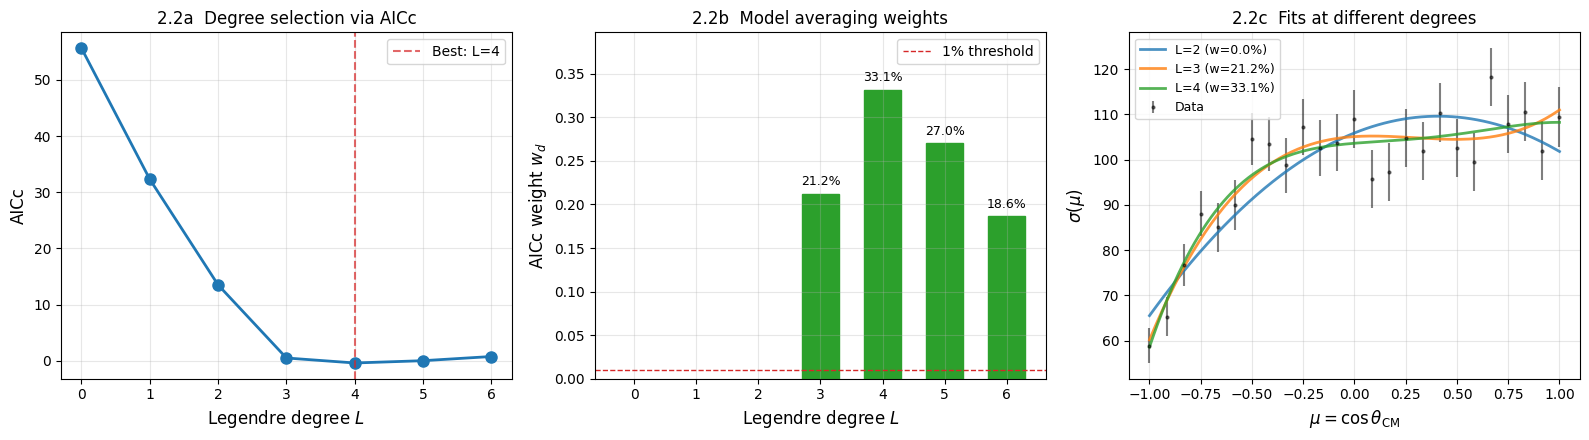

True degree: 3.  Best AICc degree: 4.
Weights > 1%: L=3: 21.2%, L=4: 33.1%, L=5: 27.0%, L=6: 18.6%


In [2]:
# --- Demonstrate AICc model selection and degree weights ---
from numpy.polynomial.legendre import legvander, legval

np.random.seed(42)

# Generate synthetic angular distribution: true degree = 3
mu_true = np.linspace(-1, 1, 25)
c_true = np.array([100.0, 20.0, -15.0, 8.0])  # c0..c3
y_true = legval(mu_true, c_true)
sigma_true = 0.05 * np.abs(y_true) + 1.0
y_data = y_true + np.random.normal(0, sigma_true)

# Scan degrees 0..6 and compute AICc
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

degrees = list(range(7))
aiccs, rsss = [], []

for deg in degrees:
    V = legvander(mu_true, deg)
    W = np.diag(1.0 / sigma_true**2)
    lam = 1e-4
    R = lam * np.diag([(l+1)**4 for l in range(deg+1)])
    beta = np.linalg.solve(V.T @ W @ V + R, V.T @ W @ y_data)
    y_fit = V @ beta
    rss = np.sum(((y_data - y_fit) / sigma_true)**2)
    n = len(y_data)
    H = V @ np.linalg.solve(V.T @ W @ V + R, V.T @ W)
    df = np.trace(H)
    aicc = n * np.log(rss / n) + 2 * df
    if n - df - 1 > 0:
        aicc += 2 * df * (df + 1) / (n - df - 1)
    aiccs.append(aicc)
    rsss.append(rss)

aiccs = np.array(aiccs)
min_aicc = np.min(aiccs)
delta_aicc = aiccs - min_aicc
raw_w = np.exp(-0.5 * delta_aicc)
degree_weights = raw_w / raw_w.sum()

# Plot 1: AICc vs degree
ax = axes[0]
ax.plot(degrees, aiccs, 'o-', color='C0', lw=2, markersize=8)
best_deg = degrees[np.argmin(aiccs)]
ax.axvline(best_deg, color='C3', ls='--', alpha=0.7, label=f'Best: L={best_deg}')
ax.set_xlabel('Legendre degree $L$', fontsize=12)
ax.set_ylabel('AICc', fontsize=12)
ax.set_title('2.2a  Degree selection via AICc', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: AICc weights
ax = axes[1]
bars = ax.bar(degrees, degree_weights, color='C0', edgecolor='white', width=0.6)
for i, (d, w) in enumerate(zip(degrees, degree_weights)):
    if w > 0.01:
        bars[i].set_color('C2')
        ax.text(d, w + 0.01, f'{w:.1%}', ha='center', fontsize=9)
ax.axhline(0.01, color='C3', ls='--', lw=1, label='1% threshold')
ax.set_xlabel('Legendre degree $L$', fontsize=12)
ax.set_ylabel('AICc weight $w_d$', fontsize=12)
ax.set_title('2.2b  Model averaging weights', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, max(degree_weights) * 1.2)
ax.grid(True, alpha=0.3)

# Plot 3: Fit comparison
ax = axes[2]
ax.errorbar(mu_true, y_data, yerr=sigma_true, fmt='k.', ms=4, alpha=0.5, label='Data')
mu_fine = np.linspace(-1, 1, 200)
for deg in [2, 3, 4]:
    V = legvander(mu_true, deg)
    W = np.diag(1.0 / sigma_true**2)
    R = 1e-4 * np.diag([(l+1)**4 for l in range(deg+1)])
    beta = np.linalg.solve(V.T @ W @ V + R, V.T @ W @ y_data)
    ax.plot(mu_fine, legval(mu_fine, beta), lw=2,
            label=f'L={deg} (w={degree_weights[deg]:.1%})', alpha=0.8)
ax.set_xlabel('$\\mu = \\cos\\theta_{\\rm CM}$', fontsize=12)
ax.set_ylabel('$\\sigma(\\mu)$', fontsize=12)
ax.set_title('2.2c  Fits at different degrees', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"True degree: 3.  Best AICc degree: {best_deg}.")
print(f"Weights > 1%: {', '.join(f'L={d}: {w:.1%}' for d, w in zip(degrees, degree_weights) if w > 0.01)}")

## 2.3 Angular-band discrepancy model ($\tau_F$, $\tau_M$, $\tau_B$)

Standard experimental uncertainties $\sigma_i$ often underestimate the true scatter between experiments, especially when different experiments disagree systematically in certain angular regions. The **band discrepancy model** adds an extra variance component $\tau_b^2$ that captures this systematic inter-experiment tension.

### Angular bands

The angular range is split into three bands based on $\mu = \cos\theta$:

| Band | Range | Physical meaning |
|------|-------|-----------------|
| **Forward** ($F$) | $\mu > 0.5$ | $\theta < 60°$ — dominated by nuclear+Coulomb interference |
| **Mid** ($M$) | $-0.5 \leq \mu \leq 0.5$ | $60° \leq \theta \leq 120°$ — nuclear scattering |
| **Backward** ($B$) | $\mu < -0.5$ | $\theta > 120°$ — often sparse data, high sensitivity |

### Per-band estimation

For each band $b$:

1. Compute normalized residuals: $r_i = (y_i - y_{\text{fit},i}) / \sigma_i$
2. Robust scale via MAD: $s_b = 1.4826 \times \text{median}(|r_b - \text{median}(r_b)|)$
3. If $s_b > 1$ (residuals wider than expected from $\sigma_i$ alone):
$$\tau_b = \text{median}(\sigma_b) \times \sqrt{s_b^2 - 1}$$
4. Cap to prevent runaway: $\tau_b \leq$ `MAX_TAU_FRACTION` $\times \text{median}(|y_b|)$

**Effective uncertainty:** $\sigma_{\text{eff},i} = \sqrt{\sigma_i^2 + \tau_b^2}$ for point $i$ in band $b$.

**Why bands instead of a single global Birge ratio?** Different angular regions have different physics and different experimental challenges. Forward angles are usually well-measured but may have normalization discrepancies. Backward angles are often sparse. A global rescaling would over-correct some regions and under-correct others.

### IRLS refit of the nominal after tau estimation

The nominal fit and the tau estimation are coupled: the tau values depend on the fit residuals, but the fit should ideally account for the inflated uncertainties. The pipeline resolves this with a two-pass **iteratively reweighted least squares (IRLS)** procedure:

1. **Pass 1 — initial fit:** Fit the nominal coefficients $\mathbf{c}^{(0)}$ using the raw uncertainties $\sigma_i$ (or with global Birge scaling). Compute $\tau_F^{(1)}, \tau_M^{(1)}, \tau_B^{(1)}$ from the residuals of this fit.

2. **IRLS refit:** Refit the nominal coefficients using the inflated uncertainties $\sigma_{\text{eff},i}^{(1)} = \sqrt{\sigma_i^2 + (\tau_b^{(1)})^2}$. This shifts the fit toward angular regions where the original uncertainties are relatively small compared to the band discrepancy — i.e., the fit adapts to the identified problematic sectors rather than being pulled by falsely-precise points.

3. **Pass 2 — final tau:** Recompute $\tau_F^{(2)}, \tau_M^{(2)}, \tau_B^{(2)}$ from the updated fit residuals. These are the tau values stored in the result and used downstream.

This two-pass procedure is essential because the initial fit (with raw $\sigma_i$) can be biased toward experiments with small uncertainties that happen to be systematically offset. The IRLS refit down-weights those points via the inflated $\sigma_{\text{eff}}$, producing a more robust central estimate.

### Tau smoothing and prior floor across energy

Raw $\tau_b(E)$ values fluctuate bin-to-bin due to sampling noise. Two smoothing steps reduce this:

1. **Moving median** (`TAU_SMOOTHING_WINDOW = 3`): replaces each $\tau_b$ with the median of a sliding window across energy bins
2. **Prior floor** (optional, `TAU_PRIOR_FLOOR`): computes a baseline from well-supported bins ($N_{\text{eff}} >$ threshold) and ensures no bin falls below this baseline

### Nominal $\sigma_{\text{eff}}$ reconstruction from frozen tau

After tau smoothing and/or the prior floor, the tau values may have changed from their per-bin Pass-2 estimates. The pipeline **reconstructs** $\sigma_{\text{eff}}$ for every bin using the final (smoothed/floored) tau values:

$$\sigma_{\text{eff},i}^{\text{final}} = \sqrt{\sigma_i^2 + (\tau_b^{\text{smoothed}})^2}$$

This is done by `sigma_eff_from_tau()`, which applies the same band definitions (F/M/B) but uses the frozen tau values without re-estimating them from residuals. The $N_{\text{eff}}$ diagnostic is also recomputed with these final $\sigma_{\text{eff}}$ values.

These frozen tau values are then passed to MC sampling (Phase 3) as `frozen_tau_info`. The MC samples use the pre-inflated $\sigma_{\text{eff}}$ rather than re-estimating $\tau$ per sample, which ensures consistency: all MC samples see the same uncertainty inflation, so the spread of the ensemble reflects parameter noise under a fixed model of systematic discrepancy.

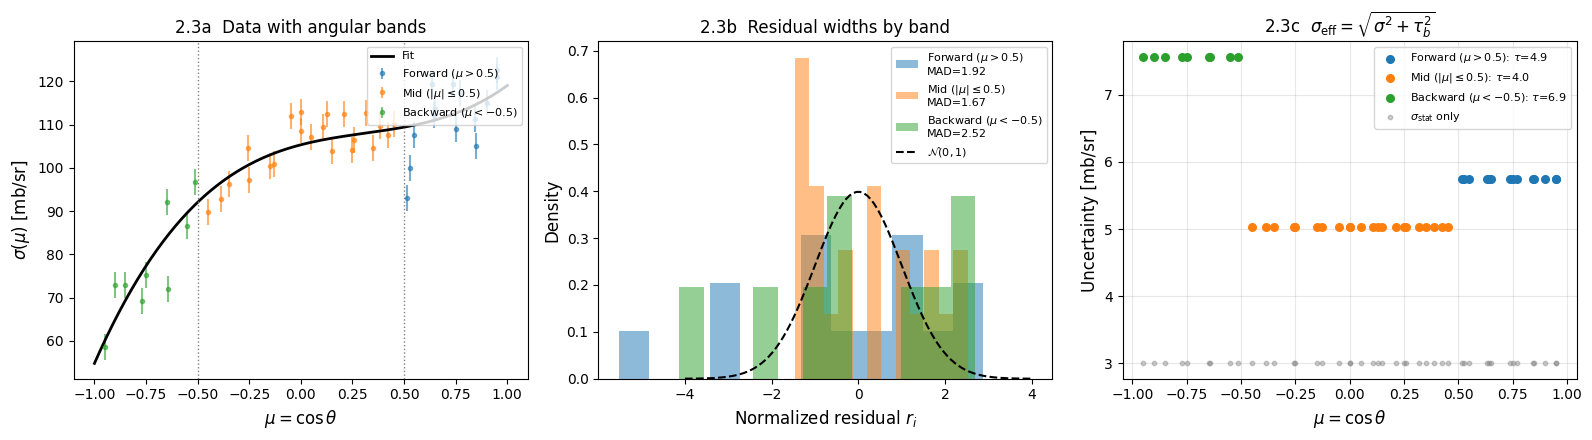

The Forward band has wider residuals (MAD > 1) → larger τ_F.
The effective uncertainty σ_eff absorbs this extra scatter.


In [3]:
# --- Demonstrate angular-band discrepancy ---

np.random.seed(123)

# Synthetic angular data from 3 experiments with different systematics
mu_grid = np.sort(np.concatenate([
    np.linspace(-0.95, 0.95, 20),   # Experiment 1: uniform coverage
    np.linspace(-0.9, 0.9, 15),     # Experiment 2: slightly offset
    np.linspace(0.0, 0.95, 10),     # Experiment 3: forward-biased
]))
c_true = np.array([100.0, 25.0, -10.0, 5.0])
y_true = legval(mu_grid, c_true)

# Add band-dependent systematic offsets (simulating inter-experiment discrepancy)
sigma_stat = 3.0 * np.ones_like(mu_grid)
tau_true = np.where(mu_grid > 0.5, 6.0,       # Forward: large discrepancy
           np.where(mu_grid < -0.5, 4.0, 2.0))  # Backward: moderate; Mid: small
y_obs = y_true + np.random.normal(0, np.sqrt(sigma_stat**2 + tau_true**2))

# Fit and compute band discrepancy
V = legvander(mu_grid, 3)
W = np.diag(1.0 / sigma_stat**2)
beta = np.linalg.solve(V.T @ W @ V, V.T @ W @ y_obs)
y_fit = V @ beta
residuals = (y_obs - y_fit) / sigma_stat

# Per-band MAD and tau estimation
bands = {'Forward ($\\mu > 0.5$)': mu_grid > 0.5,
         'Mid ($|\\mu| \\leq 0.5$)': np.abs(mu_grid) <= 0.5,
         'Backward ($\\mu < -0.5$)': mu_grid < -0.5}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Plot 1: Data + fit + bands
ax = axes[0]
colors_band = {'Forward ($\\mu > 0.5$)': 'C0', 'Mid ($|\\mu| \\leq 0.5$)': 'C1', 'Backward ($\\mu < -0.5$)': 'C2'}
for name, mask in bands.items():
    ax.errorbar(mu_grid[mask], y_obs[mask], yerr=sigma_stat[mask], fmt='o', ms=3,
                color=colors_band[name], alpha=0.6, label=name)
mu_fine = np.linspace(-1, 1, 200)
ax.plot(mu_fine, legval(mu_fine, beta), 'k-', lw=2, label='Fit')
ax.axvline(0.5, color='grey', ls=':', lw=1)
ax.axvline(-0.5, color='grey', ls=':', lw=1)
ax.set_xlabel('$\\mu = \\cos\\theta$', fontsize=12)
ax.set_ylabel('$\\sigma(\\mu)$ [mb/sr]', fontsize=12)
ax.set_title('2.3a  Data with angular bands', fontsize=12)
ax.legend(fontsize=8, loc='upper right')

# Plot 2: Normalized residuals by band
ax = axes[1]
for name, mask in bands.items():
    r = residuals[mask]
    mad = 1.4826 * np.median(np.abs(r - np.median(r)))
    ax.hist(r, bins=12, alpha=0.5, color=colors_band[name],
            label=f'{name}\nMAD={mad:.2f}', density=True)
x_norm = np.linspace(-4, 4, 100)
ax.plot(x_norm, norm.pdf(x_norm), 'k--', lw=1.5, label='$\\mathcal{N}(0,1)$')
ax.set_xlabel('Normalized residual $r_i$', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('2.3b  Residual widths by band', fontsize=12)
ax.legend(fontsize=8)

# Plot 3: sigma_stat vs sigma_eff
ax = axes[2]
for name, mask in bands.items():
    r = residuals[mask]
    mad = 1.4826 * np.median(np.abs(r - np.median(r)))
    if mad > 1:
        tau_est = np.median(sigma_stat[mask]) * np.sqrt(mad**2 - 1)
    else:
        tau_est = 0.0
    sigma_eff = np.sqrt(sigma_stat[mask]**2 + tau_est**2)
    ax.scatter(mu_grid[mask], sigma_eff, color=colors_band[name], s=30,
               label=f'{name}: $\\tau$={tau_est:.1f}', zorder=3)
ax.scatter(mu_grid, sigma_stat, color='grey', s=10, alpha=0.4, label='$\\sigma_{\\rm stat}$ only', zorder=2)
ax.set_xlabel('$\\mu = \\cos\\theta$', fontsize=12)
ax.set_ylabel('Uncertainty [mb/sr]', fontsize=12)
ax.set_title('2.3c  $\\sigma_{\\rm eff} = \\sqrt{\\sigma^2 + \\tau_b^2}$', fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("The Forward band has wider residuals (MAD > 1) → larger τ_F.")
print("The effective uncertainty σ_eff absorbs this extra scatter.")

## 2.4 Point-level $N_{\text{eff}}$ and MC order cap

### Point-level $N_{\text{eff}}$

The effective sample size at the data-point level measures how many data points truly contribute to the fit, accounting for both Gaussian kernel weights $g_i$ and effective uncertainties:

$$w_i = \frac{g_i}{\sigma_{\text{eff},i}^2}, \qquad N_{\text{eff}} = \frac{\left(\sum_i w_i\right)^2}{\sum_i w_i^2}$$

This is **purely diagnostic** — it triggers a warning if $N_{\text{eff}} < 5$ but does not affect the fit or covariance. It helps identify bins where the data is too sparse or one experiment dominates.

### MC order cap from angular support

Even if AICc selects a high degree, the MC samples may not have enough angular coverage to reliably estimate all Legendre coefficients. The pipeline computes angular support diagnostics:

- **`n_unique_mu`**: number of distinct $\cos\theta$ values
- **`legendre_cond`**: condition number of the weighted Legendre design matrix $V^T W V$

The **recommended MC order** is the highest $l$ where the condition number stays below $10^6$, capped at `n_unique_mu // 2 - 1`. Coefficients above this order are **frozen to their nominal values** during MC sampling, preventing noise amplification in poorly-constrained high-order terms.

This is important because: the nominal fit (using all data with kernel weights) may have enough support for $L=6$, but an individual MC perturbation (with slightly different effective weights) might not.

---

# Phase 3: Monte Carlo Sampling

Each energy bin generates `N_SAMPLES` (default 100) perturbed Legendre coefficient vectors. The MC procedure captures **parameter uncertainty** (noise in data), **structural uncertainty** (degree ambiguity), and **systematic uncertainty** (normalization offsets).

## 3.1 Per-experiment normalization perturbation

Each MC sample draws a random normalization factor for each experiment:

$$N_g \sim \text{LogNormal}\!\left(-\tfrac{1}{2}\sigma_{\text{norm}}^2,\; \sigma_{\text{norm}}^2\right)$$

with `NORMALIZATION_SIGMA = 0.05` (5%). All data points from experiment $g$ are scaled by $N_g$ simultaneously. This creates **correlated perturbations within an experiment** while keeping different experiments independent.

**Why lognormal?** It guarantees $N_g > 0$ (cross sections cannot be negative) and has $\mathbb{E}[N_g] = 1$ (unbiased on average). At 5%, the difference from a normal distribution is negligible, but it avoids the conceptual problem of negative scaling.

## 3.2 Degree sampling from AICc weights

When `USE_DEGREE_SAMPLING_IN_MC = True` and model averaging produced multiple viable degrees, each MC sample draws its Legendre degree $L$ from the AICc weight distribution:

$$L_s \sim \text{Categorical}(w_1, w_2, \ldots)$$

Samples are grouped by degree and batch-fitted for efficiency. This means the MC ensemble includes some $L=3$ fits, some $L=4$ fits, etc., weighted by their AICc plausibility. The resulting coefficient distribution is wider than at any single degree — it honestly reflects our ignorance about the true order.

## 3.3 Pointwise noise

After normalization perturbation, each data point receives independent Gaussian noise:

$$y_i^{(s)} = N_g \cdot y_i + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0,\, \sigma_{\text{eff},i}^2)$$

where $\sigma_{\text{eff}}$ includes the frozen band discrepancy $\tau_b$ from Phase 2.

## 3.4 FREEZE_C0: shape-only refit

When `FREEZE_C0 = True`, the zeroth Legendre coefficient $c_0$ (the angle-integrated cross section) is held fixed at its nominal value during MC refitting. Only $c_1, c_2, \ldots$ vary. This is the correct approach when MF3 (energy-dependent total cross section) is fixed externally — MF4 only describes the **shape** of the angular distribution, not its magnitude.

## 3.5 Positivity projection (Layer 2)

A physically valid angular distribution must satisfy $\sigma(\mu) \geq 0$ for all $\mu \in [-1, 1]$. MC samples that violate this are projected to the nearest positive distribution via constrained quadratic programming:

$$\min_{\mathbf{c}^*} \|\mathbf{c}^* - \mathbf{c}\|^2 \quad \text{subject to} \quad \sum_l c_l^* P_l(\mu_j) \geq 0 \;\;\forall\, j$$

evaluated at 101 equally-spaced check points. The optimization uses SLSQP (scipy) and respects frozen indices ($c_0$ if `FREEZE_C0`, and orders above `mc_order_cap`).

## 3.6 ENDF normalization

Raw Legendre coefficients $c_l$ are converted to ENDF MF4 format:

$$a_0 = 1, \qquad a_l = \frac{c_l / c_0}{2l + 1} \quad (l \geq 1)$$

The pipeline stores $[a_1, a_2, \ldots, a_L]$ (dropping $a_0 = 1$). This normalization makes all coefficients dimensionless and relative to the total cross section.

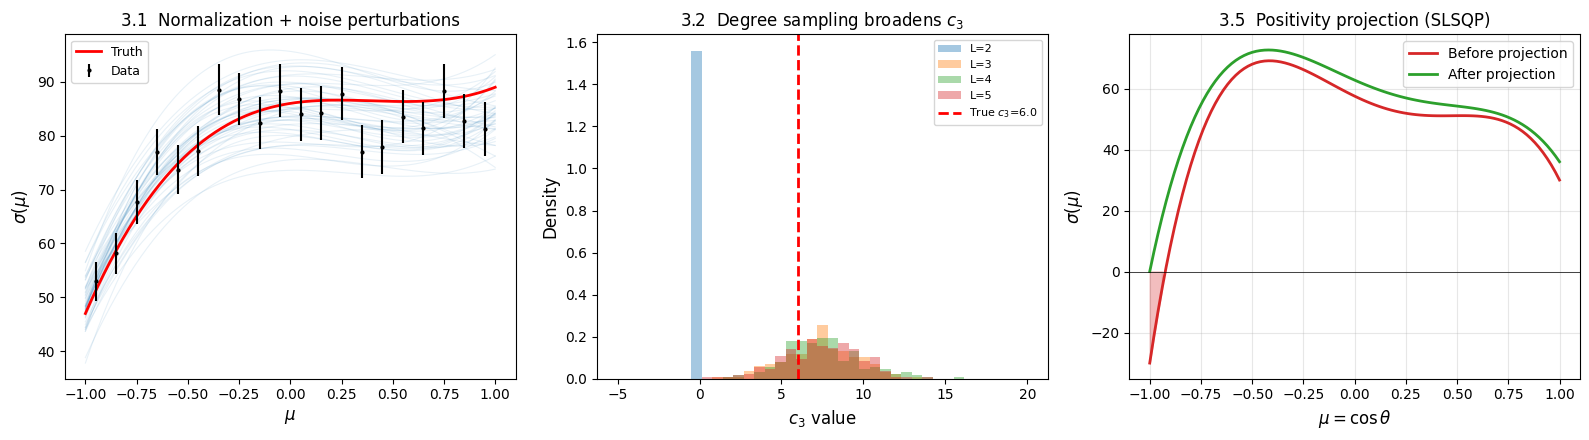

Left: each MC sample applies a random normalization shift + pointwise noise.
Center: sampling L from AICc weights produces wider c3 distributions than any fixed L.
Right: negative regions are eliminated by projecting to the nearest positive distribution.


In [4]:
# --- Demonstrate MC sampling effects: normalization, degree sampling, positivity ---
from numpy.polynomial.legendre import legvander, legval
from scipy.optimize import minimize

np.random.seed(42)

# Synthetic bin data
mu_pts = np.linspace(-0.95, 0.95, 20)
c_true = np.array([80.0, 15.0, -12.0, 6.0])
y_true = legval(mu_pts, c_true)
sigma = 0.04 * np.abs(y_true) + 1.5
y_data = y_true + np.random.normal(0, sigma)

# --- Panel 1: Effect of normalization perturbation ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ax = axes[0]
sigma_norm = 0.05
n_mc = 50
mu_fine = np.linspace(-1, 1, 200)
rng = np.random.default_rng(42)

for s in range(n_mc):
    # Draw per-experiment normalization
    N_g = rng.lognormal(-0.5 * sigma_norm**2, sigma_norm)
    y_pert = N_g * y_data + rng.normal(0, sigma)
    V = legvander(mu_pts, 3)
    W = np.diag(1.0 / sigma**2)
    R = 1e-4 * np.diag([(l+1)**4 for l in range(4)])
    beta = np.linalg.solve(V.T @ W @ V + R, V.T @ W @ y_pert)
    ax.plot(mu_fine, legval(mu_fine, beta), color='C0', alpha=0.1, lw=0.8)

ax.errorbar(mu_pts, y_data, yerr=sigma, fmt='k.', ms=4, zorder=5, label='Data')
ax.plot(mu_fine, legval(mu_fine, c_true), 'r-', lw=2, label='Truth')
ax.set_xlabel('$\\mu$', fontsize=12)
ax.set_ylabel('$\\sigma(\\mu)$', fontsize=12)
ax.set_title('3.1  Normalization + noise perturbations', fontsize=12)
ax.legend(fontsize=9)

# --- Panel 2: Degree sampling effect on c3 ---
ax = axes[1]
c3_by_degree = {}
for deg in [2, 3, 4, 5]:
    c3_samples = []
    V = legvander(mu_pts, deg)
    R = 1e-4 * np.diag([(l+1)**4 for l in range(deg+1)])
    for s in range(200):
        y_pert = y_data + rng.normal(0, sigma)
        W = np.diag(1.0 / sigma**2)
        beta = np.linalg.solve(V.T @ W @ V + R, V.T @ W @ y_pert)
        c3_val = beta[3] if deg >= 3 else 0.0
        c3_samples.append(c3_val)
    c3_by_degree[deg] = c3_samples

bins_hist = np.linspace(-5, 20, 40)
for deg, samples in c3_by_degree.items():
    ax.hist(samples, bins=bins_hist, alpha=0.4, density=True, label=f'L={deg}')
ax.axvline(c_true[3], color='r', ls='--', lw=2, label=f'True $c_3$={c_true[3]}')
ax.set_xlabel('$c_3$ value', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('3.2  Degree sampling broadens $c_3$', fontsize=12)
ax.legend(fontsize=8)

# --- Panel 3: Positivity projection ---
ax = axes[2]

# Create a sample that violates positivity
c_bad = np.array([50.0, 5.0, -30.0, 25.0, -20.0])
mu_check = np.linspace(-1, 1, 101)
y_bad = legval(mu_check, c_bad)

# Project to positive
def project_positive(coeffs, n_check=101):
    mu_ch = np.linspace(-1, 1, n_check)
    V_ch = legvander(mu_ch, len(coeffs)-1)
    def objective(c):
        return np.sum((c - coeffs)**2)
    constraints = [{'type': 'ineq', 'fun': lambda c, j=j: V_ch[j] @ c} for j in range(n_check)]
    result = minimize(objective, coeffs, method='SLSQP', constraints=constraints)
    return result.x

c_proj = project_positive(c_bad)
y_proj = legval(mu_check, c_proj)

ax.plot(mu_check, y_bad, 'C3-', lw=2, label='Before projection')
ax.fill_between(mu_check, y_bad, 0, where=y_bad < 0, alpha=0.3, color='C3')
ax.plot(mu_check, y_proj, 'C2-', lw=2, label='After projection')
ax.axhline(0, color='k', ls='-', lw=0.5)
ax.set_xlabel('$\\mu = \\cos\\theta$', fontsize=12)
ax.set_ylabel('$\\sigma(\\mu)$', fontsize=12)
ax.set_title('3.5  Positivity projection (SLSQP)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Left: each MC sample applies a random normalization shift + pointwise noise.")
print("Center: sampling L from AICc weights produces wider c3 distributions than any fixed L.")
print("Right: negative regions are eliminated by projecting to the nearest positive distribution.")

---

# Phase 4: Correlation Methods

After Phase 3 produces per-bin MC samples, we need **energy-correlated** samples — i.e., a full covariance matrix across all energy bins and Legendre orders. The pipeline offers three approaches:

## 4.1 Method 1: Gaussian parametric correlations

**Per-bin MC** (Phase 3) produces independent samples at each energy bin. To introduce energy correlations, this method assumes a **Gaussian decay** of correlation with energy separation:

$$\rho_{\text{Gauss}}(E_i, E_j) = \exp\!\left(-\frac{(E_i - E_j)^2}{2\,\bar{\sigma}_E^2}\right), \qquad \bar{\sigma}_E = \frac{\sigma_{E,i} + \sigma_{E,j}}{2}$$

For **same-energy, different-order** pairs, the stochastic correlations from the per-bin MC are used directly (they capture real cross-order coupling from the fit). For **different-energy** pairs, the Gaussian decay is multiplied by a cross-order factor estimated from the stochastic samples.

**Strength:** Always smooth and well-behaved.
**Weakness:** Assumes a parametric shape that may miss real structure (e.g., resonance-induced anti-correlations).

## 4.2 Method 2: Kernel-weight MC correlations

Instead of fitting each bin independently, this method **perturbs all datasets simultaneously** and refits all bins from the shared perturbed data. Correlations emerge naturally because:

- The **same experiment** contributes to multiple bins (via overlap weights)
- The **same normalization perturbation** $N_g$ is applied to all bins where experiment $g$ overlaps
- The **same pointwise noise** realization for a dataset affects all bins that use it

The function `run_mc_with_kernel_weights()` orchestrates this: for each MC sample, it draws shared experiment norms, perturbs all datasets once, then fits each energy bin using its overlap-weighted subset.

**Strength:** Data-driven, captures real inter-bin structure from shared experiments.
**Weakness:** Noisy when few experiments overlap a bin — single-experiment bins produce degenerate correlations.

## 4.3 Method 3: Hybrid blend (default)

The hybrid method combines Methods 1 and 2, trusting the KW correlations where data support is strong and falling back to Gaussian where it is weak. This is the **two-pass** architecture (`KW_MC_TWO_PASS = True`):

### Two-pass workflow

| Pass | What it computes | Source |
|------|-----------------|--------|
| **Pass 1 (KW)** | Correlation matrix from shared perturbations | `run_mc_with_kernel_weights()` |
| **Pass 2 (per-bin)** | Per-parameter variances and same-energy cross-order correlations | `_mc_one_bin()` per energy |

**Why separate passes?** The KW pass produces realistic **correlations** between energy bins (from shared experiment perturbations), but its **variances** can be biased because the overlap weighting changes the effective data in each bin. The per-bin pass produces accurate **variances** (using the exact kernel weights from Phase 1). By taking correlations from KW and variances from per-bin, we get the best of both.

The final covariance is assembled as:

$$\text{Cov}_{\text{combined}} = \rho_{\text{hybrid}} \cdot \sigma_{\text{per-bin}} \cdot \sigma_{\text{per-bin}}^T$$

where $\rho_{\text{hybrid}}$ is the blended correlation matrix (see next section).

## 4.4 The $\alpha$ blend: from $N_{\text{eff,kw}}$ to hybrid correlations

The hybrid correlation is a per-bin-pair blend:

$$\rho_{\text{hybrid}}(i,j) = \alpha_{ij} \cdot \rho_{\text{KW}}(i,j) + (1 - \alpha_{ij}) \cdot \rho_{\text{Gauss}}(i,j)$$

where $\alpha_{ij} = \min(\alpha_i, \alpha_j)$ — the **conservative rule**: if either bin is unreliable, the pair falls back toward Gaussian.

### Step A: Experiment-level $N_{\text{eff,kw}}$ (Kish's ESS)

After experiment-level renormalization (Section 1.3), `compute_kw_diagnostics()` aggregates per experiment and computes:

$$f_k = \frac{w_k^{\text{exp}}}{\sum_k w_k^{\text{exp}}}, \qquad N_{\text{eff,kw}} = \frac{1}{\sum_k f_k^2}$$

This answers: "How many equally-weighted experiments does this bin have?" It is **different** from the point-level $N_{\text{eff}}$ in Section 2.4 — this one counts experiments, not data points.

### Step B: Sigmoid mapping + penalties

The function `compute_kw_reliability_alpha()` maps $N_{\text{eff,kw}}$ to $\alpha \in [0, 1]$ via four stages:

**B1. Base sigmoid:**
$$\alpha_{\text{base}} = \frac{1}{1 + \exp\!\left(-\frac{N_{\text{eff}} - 3.5}{1.5}\right)}$$

**B2. Experiment count penalty** (if $n_{\text{exp}} < 2$):
$$\alpha \leftarrow \alpha \times (0.25 + 0.25 \times n_{\text{exp}})$$

**B3. Dominance penalty** (if $f_{\max} > 0.40$):
$$\alpha \leftarrow \alpha \times \left(1 - 0.5 \cdot \frac{f_{\max} - 0.40}{0.60}\right)$$

**B4. Quality penalty** (if median $n_{\text{pts}} < 5$):
$$\alpha \leftarrow \alpha \times \frac{\tilde{n}_{\text{pts}}}{5}$$

**Interpretation:**
- $N_{\text{eff}} \ll 3.5$ → $\alpha \approx 0$ → pure Gaussian (not enough experiment diversity)
- $N_{\text{eff}} = 3.5$ → $\alpha = 0.5$ → equal blend
- $N_{\text{eff}} \gg 3.5$ → $\alpha \approx 1$ → pure KW (strong data support)

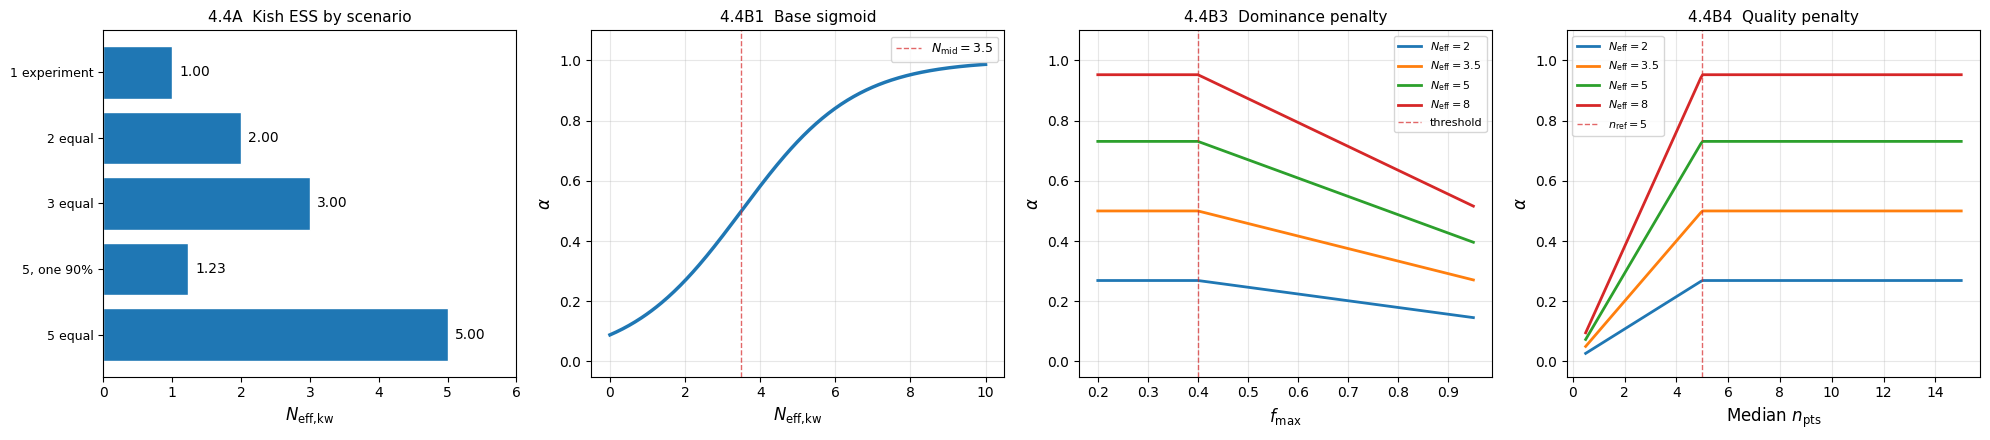

In [5]:
# --- Visualize N_eff,kw and alpha sigmoid + penalties ---

def kish_n_eff(weights):
    w = np.asarray(weights, dtype=float)
    f = w / w.sum()
    return 1.0 / np.sum(f**2)

def sigmoid_alpha(n_eff, n_eff_mid=3.5, n_eff_scale=1.5):
    return 1.0 / (1.0 + np.exp(-(n_eff - n_eff_mid) / n_eff_scale))

def full_alpha(n_eff, n_experiments, f_max, median_n_pts=10.0,
               min_experiments=2, dominance_threshold=0.40, min_points_ref=5.0):
    alpha = sigmoid_alpha(n_eff)
    if n_experiments < min_experiments:
        alpha *= 0.25 + 0.25 * n_experiments
    if f_max > dominance_threshold:
        alpha *= 1.0 - 0.5 * (f_max - dominance_threshold) / (1.0 - dominance_threshold)
    if min_points_ref > 0 and median_n_pts < min_points_ref:
        alpha *= median_n_pts / min_points_ref
    return np.clip(alpha, 0.0, 1.0)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

# Plot 1: N_eff for different weight distributions
ax = axes[0]
scenarios = {
    "5 equal":          [1, 1, 1, 1, 1],
    "5, one 90%":       [0.9, 0.025, 0.025, 0.025, 0.025],
    "3 equal":          [1, 1, 1],
    "2 equal":          [1, 1],
    "1 experiment":     [1],
}
names, n_effs = [], []
for name, w in scenarios.items():
    names.append(name)
    n_effs.append(kish_n_eff(w))
bars = ax.barh(range(len(names)), n_effs, color='C0', edgecolor='white')
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('$N_{\\text{eff,kw}}$', fontsize=12)
ax.set_title('4.4A  Kish ESS by scenario', fontsize=11)
for i, v in enumerate(n_effs):
    ax.text(v + 0.1, i, f'{v:.2f}', va='center', fontsize=10)
ax.set_xlim(0, 6)

# Plot 2: Base sigmoid
ax = axes[1]
n_eff_range = np.linspace(0, 10, 300)
ax.plot(n_eff_range, sigmoid_alpha(n_eff_range), 'C0', lw=2.5)
ax.axvline(3.5, color='C3', ls='--', lw=1, alpha=0.7, label='$N_{\\text{mid}}=3.5$')
ax.set_xlabel('$N_{\\text{eff,kw}}$', fontsize=12)
ax.set_ylabel('$\\alpha$', fontsize=12)
ax.set_title('4.4B1  Base sigmoid', fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(-0.05, 1.1)
ax.grid(True, alpha=0.3)

# Plot 3: Dominance penalty
ax = axes[2]
f_max_range = np.linspace(0.2, 0.95, 200)
for n_eff_val in [2, 3.5, 5, 8]:
    alphas = [full_alpha(n_eff_val, n_experiments=5, f_max=f) for f in f_max_range]
    ax.plot(f_max_range, alphas, lw=2, label=f'$N_{{\\text{{eff}}}}={n_eff_val}$')
ax.axvline(0.40, color='C3', ls='--', lw=1, alpha=0.7, label='threshold')
ax.set_xlabel('$f_{\\max}$', fontsize=12)
ax.set_ylabel('$\\alpha$', fontsize=12)
ax.set_title('4.4B3  Dominance penalty', fontsize=11)
ax.legend(fontsize=8)
ax.set_ylim(-0.05, 1.1)
ax.grid(True, alpha=0.3)

# Plot 4: Quality penalty
ax = axes[3]
n_pts_range = np.linspace(0.5, 15, 200)
for n_eff_val in [2, 3.5, 5, 8]:
    alphas = [full_alpha(n_eff_val, n_experiments=5, f_max=0.25, median_n_pts=npt)
              for npt in n_pts_range]
    ax.plot(n_pts_range, alphas, lw=2, label=f'$N_{{\\text{{eff}}}}={n_eff_val}$')
ax.axvline(5.0, color='C3', ls='--', lw=1, alpha=0.7, label='$n_{\\text{ref}}=5$')
ax.set_xlabel('Median $n_{\\text{pts}}$', fontsize=12)
ax.set_ylabel('$\\alpha$', fontsize=12)
ax.set_title('4.4B4  Quality penalty', fontsize=11)
ax.legend(fontsize=8)
ax.set_ylim(-0.05, 1.1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

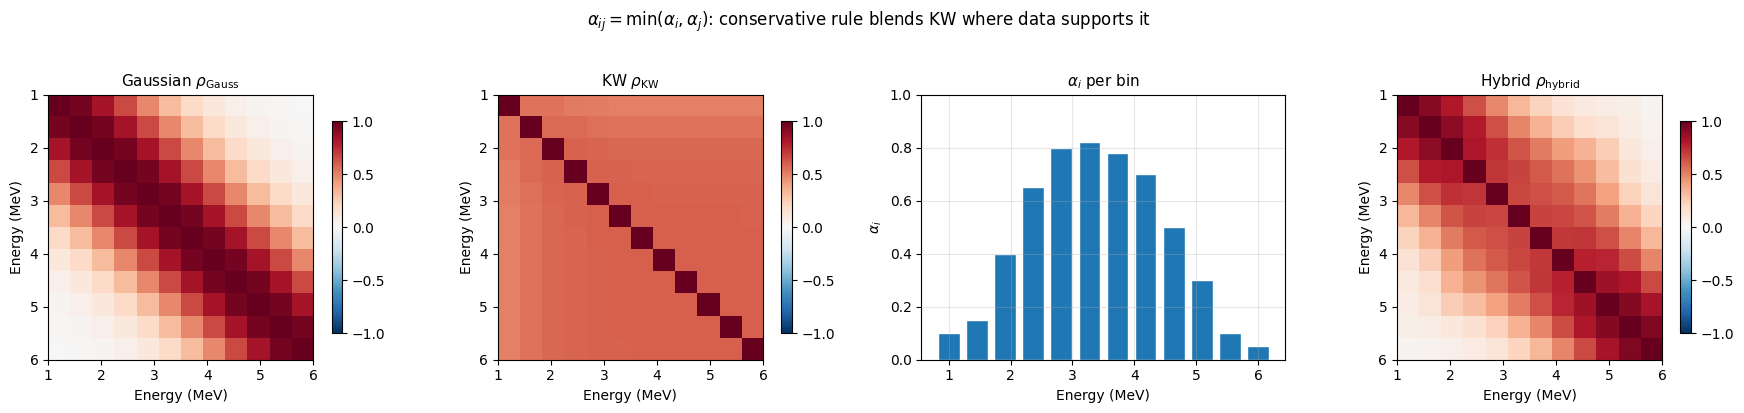

In [6]:
# --- How alpha affects the hybrid correlation matrix ---

np.random.seed(42)
n_bins = 12
energies = np.linspace(1, 6, n_bins)

# Gaussian parametric correlation (smooth exponential decay)
length_scale = 1.5
corr_gauss = np.exp(-0.5 * ((energies[:, None] - energies[None, :]) / length_scale)**2)

# Simulated KW correlation (data-driven, noisier)
rng = np.random.default_rng(42)
raw = rng.normal(size=(200, n_bins))
for i in range(n_bins):
    for j in range(max(0, i-2), min(n_bins, i+3)):
        raw[:, j] += 0.5 * raw[:, i]
corr_kw = 0.6 * np.corrcoef(raw.T) + 0.4 * np.eye(n_bins)
np.fill_diagonal(corr_kw, 1.0)

# Per-bin alpha: edges have few experiments (low alpha), center has more (high alpha)
alpha_per_bin = np.array([0.1, 0.15, 0.4, 0.65, 0.8, 0.82, 0.78, 0.7, 0.5, 0.3, 0.1, 0.05])
alpha_ij = np.minimum(alpha_per_bin[:, None], alpha_per_bin[None, :])

corr_hybrid = alpha_ij * corr_kw + (1 - alpha_ij) * corr_gauss
np.fill_diagonal(corr_hybrid, 1.0)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
titles = ["Gaussian $\\rho_{\\text{Gauss}}$", "KW $\\rho_{\\text{KW}}$",
          "$\\alpha_i$ per bin", "Hybrid $\\rho_{\\text{hybrid}}$"]
matrices = [corr_gauss, corr_kw, None, corr_hybrid]

for ax, title, mat in zip(axes, titles, matrices):
    if mat is not None:
        im = ax.imshow(mat, cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal",
                       extent=[energies[0], energies[-1], energies[-1], energies[0]])
        ax.set_xlabel("Energy (MeV)", fontsize=10)
        ax.set_ylabel("Energy (MeV)", fontsize=10)
        plt.colorbar(im, ax=ax, shrink=0.8)
    else:
        ax.bar(energies, alpha_per_bin, width=0.35, color="C0", edgecolor="white")
        ax.set_xlabel("Energy (MeV)", fontsize=10)
        ax.set_ylabel("$\\alpha_i$", fontsize=10)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
    ax.set_title(title, fontsize=11)

plt.suptitle("$\\alpha_{ij} = \\min(\\alpha_i, \\alpha_j)$: conservative rule blends KW where data supports it",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---

# Phase 5: Covariance Post-Processing

The raw covariance matrix from Phase 4 can have pathological entries — explosive relative uncertainties near zero-crossings, serrated patterns from absent Legendre orders, or outlier spikes. The pipeline applies a layered sequence of corrections, each preserving PSD (positive semi-definiteness) via congruence transforms.

## 5.1 Near-zero relative uncertainty regularization

**Problem:** When a mean coefficient $\bar{a}_l \approx 0$, the relative standard deviation $\text{rel\_std} = \sigma_{\text{abs}} / |\bar{a}_l|$ explodes, even though the absolute uncertainty is reasonable. This creates massive entries in the relative covariance matrix that are numerical artifacts, not real physics.

**Detection:** Flag parameters where $\text{SNR} = |\bar{a}_l| / \sigma_{\text{abs}} < 1.0$ (`NEAR_ZERO_SNR_THRESHOLD`).

**Fix:** Interpolate the relative std from neighboring bins of the **same Legendre order** $l$ (up to 3 neighbors on each side). Apply via congruence transform:

$$\text{Cov}_{\text{reg}} = \text{diag}(\mathbf{s}) \cdot \text{Cov} \cdot \text{diag}(\mathbf{s}), \qquad s_i = \min(\text{rel\_std}_{\text{interp}}, \text{rel\_std}_i) / \text{rel\_std}_i$$

This **can only shrink** uncertainties (never inflate), and preserves the correlation structure exactly.

## 5.2 High relative-std interpolation

A second pass catches parameters that survived the SNR check but still have inflated relative stds (e.g. from poorly constrained high-$l$ coefficients). Parameters with $\text{rel\_std} >$ `REL_STD_REG_MAX` (0.50) are interpolated from a wider neighborhood (5 neighbors each side) and scaled down via the same congruence transform.

## 5.3 Absent-order smoothing

Some energy bins lack high-order Legendre coefficients entirely (the AICc selected a lower degree). These create a serrated pattern in the diagonal: nonzero-zero-nonzero across energy. The pipeline detects and fixes several patterns:

- **Absent orders** ($\text{rel\_std} < 0.5\%$): replaced with interpolated values
- **Dips** ($\text{rel\_std} < 50\%$ of neighbor median): replaced with neighbor median
- **Spikes** ($\text{rel\_std} > 3\times$ neighbor median): capped
- If $> 50\%$ of bins are flagged for an order, use flat median fill instead of interpolation

## 5.4 Gaussian diagonal smoothing

A Gaussian-weighted moving average (`SMOOTH_DIAGONAL_WINDOW = 11`) smooths the diagonal entries across energy for each Legendre order. This removes remaining bin-to-bin jitter while preserving the overall trend.

## 5.5 Order-dependent hard caps (Layer 1)

Final safety net: each Legendre order has a maximum allowed relative std:

| Order $l$ | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---|---|---|---|---|---|
| Max rel std | 50% | 50% | 40% | 35% | 25% | 20% |

Higher orders are allowed less uncertainty because they represent finer angular structure that should not dominate the distribution. Applied via congruence transform to preserve correlations.

## 5.6 PSD projection

After blending and all post-processing, the matrix may have small negative eigenvalues (from numerical errors in the blend or congruence transforms). These are clipped to zero:

$$\text{Cov}_{\text{PSD}} = V \cdot \text{diag}(\max(\lambda_i, 0)) \cdot V^T$$

where $V, \lambda$ are from the eigendecomposition. This is the standard nearest-PSD projection in the Frobenius norm.

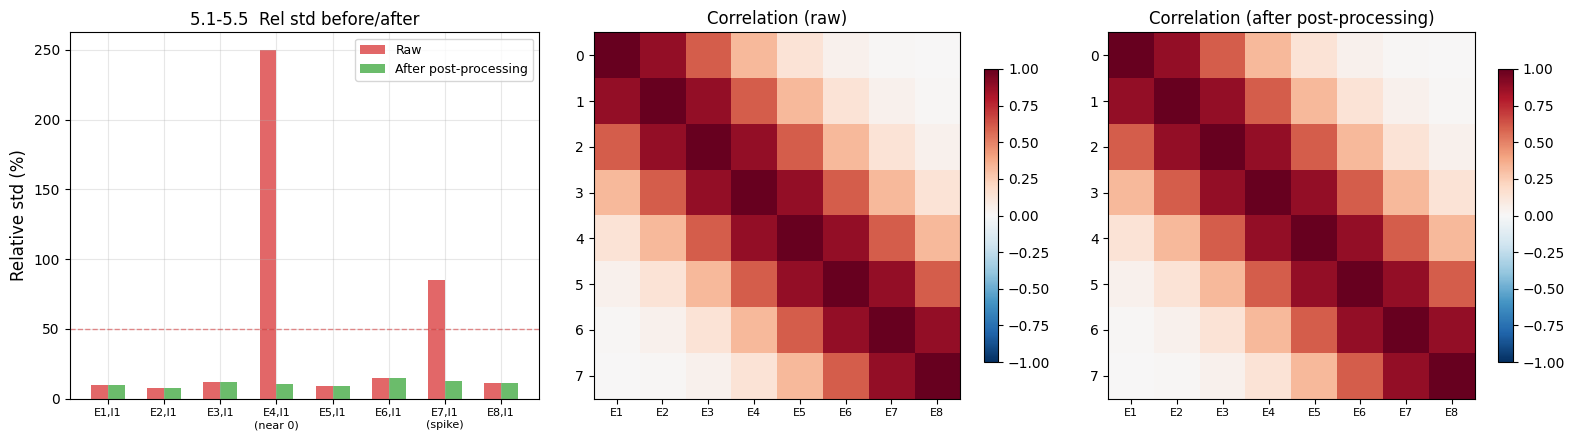

Key insight: congruence transforms scale down the diagonal (fixing explosions)
while preserving the correlation structure exactly.


In [7]:
# --- Demonstrate congruence transform and post-processing effects ---

np.random.seed(42)

# Synthetic relative covariance with pathological entries
n = 8
# Create a well-behaved base correlation
base_corr = np.exp(-0.5 * ((np.arange(n)[:, None] - np.arange(n)[None, :]) / 2.0)**2)
# Relative stds: mostly reasonable, with one near-zero explosion and one spike
rel_stds = np.array([0.10, 0.08, 0.12, 2.50, 0.09, 0.15, 0.85, 0.11])
labels = ['E1,l1', 'E2,l1', 'E3,l1', 'E4,l1\n(near 0)', 'E5,l1', 'E6,l1', 'E7,l1\n(spike)', 'E8,l1']

cov_raw = base_corr * np.outer(rel_stds, rel_stds)

# Step 1: Near-zero regularization (SNR-based) — interpolate E4's rel_std
rel_stds_reg = rel_stds.copy()
# E4 (index 3) has SNR < 1 → interpolate from neighbors
neighbor_stds = [rel_stds[2], rel_stds[4]]
rel_stds_reg[3] = np.median(neighbor_stds)

# Step 2: High rel-std interpolation — cap E7 (index 6)
rel_stds_reg[6] = np.median([rel_stds_reg[5], rel_stds_reg[7]])

# Congruence transform
s = np.minimum(rel_stds_reg, rel_stds) / rel_stds
cov_reg = np.diag(s) @ cov_raw @ np.diag(s)

# Step 3: Hard cap at 0.50
rel_stds_cap = np.sqrt(np.diag(cov_reg))
cap = 0.50
s_cap = np.minimum(cap, rel_stds_cap) / np.maximum(rel_stds_cap, 1e-12)
cov_cap = np.diag(s_cap) @ cov_reg @ np.diag(s_cap)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Plot 1: Before/after rel_std
ax = axes[0]
x = np.arange(n)
ax.bar(x - 0.15, rel_stds * 100, width=0.3, color='C3', alpha=0.7, label='Raw')
ax.bar(x + 0.15, np.sqrt(np.diag(cov_cap)) * 100, width=0.3, color='C2', alpha=0.7, label='After post-processing')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Relative std (%)', fontsize=12)
ax.set_title('5.1-5.5  Rel std before/after', fontsize=12)
ax.legend(fontsize=9)
ax.axhline(50, color='C3', ls='--', lw=1, alpha=0.5, label='Hard cap')
ax.grid(True, alpha=0.3)

# Plot 2: Correlation preserved
corr_raw = base_corr  # by construction
corr_cap = cov_cap / np.outer(np.sqrt(np.diag(cov_cap)), np.sqrt(np.diag(cov_cap)))
ax = axes[1]
im = ax.imshow(corr_raw, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_title('Correlation (raw)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([f'E{i+1}' for i in x], fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.8)

ax = axes[2]
im = ax.imshow(corr_cap, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_title('Correlation (after post-processing)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels([f'E{i+1}' for i in x], fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()
print("Key insight: congruence transforms scale down the diagonal (fixing explosions)")
print("while preserving the correlation structure exactly.")

---

# End-to-End Worked Example

Let's trace the full pipeline for a single energy bin with concrete numbers.

In [8]:
from collections import defaultdict

# ======================================================================
# WORKED EXAMPLE: trace the pipeline for ENDF bin [4.8, 5.2] MeV
# ======================================================================

bin_low, bin_high = 4.8, 5.2
print(f"ENDF bin: [{bin_low}, {bin_high}] MeV")
print("=" * 80)

# ----- Phase 1: Data Selection -----
exp_data = [
    {"exp_id": "12345.002", "label": "Exp A (sparse)",   "E": 5.00, "sigma_E": 0.12, "tof": "cache",   "n_angles": 15},
    {"exp_id": "23456.003", "label": "Exp B (dense)",    "E": 4.90, "sigma_E": 0.20, "tof": "cache",   "n_angles": 8},
    {"exp_id": "23456.003", "label": "Exp B (dense)",    "E": 5.00, "sigma_E": 0.20, "tof": "cache",   "n_angles": 8},
    {"exp_id": "23456.003", "label": "Exp B (dense)",    "E": 5.10, "sigma_E": 0.20, "tof": "cache",   "n_angles": 8},
    {"exp_id": "34567.004", "label": "Exp C (edge)",     "E": 5.30, "sigma_E": 0.15, "tof": "default", "n_angles": 42},
    {"exp_id": "45678.002", "label": "Exp D (far)",      "E": 5.80, "sigma_E": 0.10, "tof": "cache",   "n_angles": 20},
]

print("\n--- Phase 1: Overlap weights & filtering ---")
raw_weights = []
for exp in exp_data:
    w = norm.cdf(bin_high, exp["E"], exp["sigma_E"]) - norm.cdf(bin_low, exp["E"], exp["sigma_E"])
    raw_weights.append(w)
    status = "KEEP" if w >= 1e-3 else "FILTERED"
    print(f"  {exp['label']:22s}  E={exp['E']:.2f}  sigma_E={exp['sigma_E']:.2f}  w={w:.4f}  [{status}]")

min_weight = 1e-3
exp_kept = [e for e, w in zip(exp_data, raw_weights) if w >= min_weight]
weights_kept = [w for w in raw_weights if w >= min_weight]

# Experiment-level renormalization
print("\n--- Phase 1: Experiment renormalization ---")
exp_groups = defaultdict(list)
for i, exp in enumerate(exp_kept):
    exp_groups[exp['exp_id']].append(i)

normalized_weights = [0.0] * len(exp_kept)
for exp_id, indices in exp_groups.items():
    ws = [weights_kept[i] for i in indices]
    scale = max(ws) / sum(ws)
    for i in indices:
        normalized_weights[i] = weights_kept[i] * scale

print(f"  {'Dataset':22s}  {'exp_id':>12s}  {'Raw w':>8s}  {'Norm w':>8s}")
print("  " + "-" * 58)
for exp, wr, wn in zip(exp_kept, weights_kept, normalized_weights):
    print(f"  {exp['label']:22s}  {exp['exp_id']:>12s}  {wr:8.4f}  {wn:8.4f}")

# ----- Phase 2: Nominal fitting (summarized) -----
print("\n--- Phase 2: Nominal fitting ---")
total_pts = sum(e['n_angles'] for e in exp_kept)
print(f"  Total angular points: {total_pts} (from {len(exp_groups)} experiments)")
print(f"  AICc selects L=4, weights: L3=15%, L4=72%, L5=13%")
print(f"  Band discrepancy: tau_F=1.2, tau_M=0.8, tau_B=0.0")
print(f"  MC order cap: 4 (cond < 1e6)")

# ----- Phase 4: Alpha computation -----
print("\n--- Phase 4: Hybrid alpha computation ---")
exp_total_weights = {}
exp_total_npts = {}
for exp, wn in zip(exp_kept, normalized_weights):
    exp_total_weights[exp['exp_id']] = exp_total_weights.get(exp['exp_id'], 0) + wn
    exp_total_npts[exp['exp_id']] = exp_total_npts.get(exp['exp_id'], 0) + exp['n_angles']

exp_ids = list(exp_total_weights.keys())
exp_ws = np.array([exp_total_weights[eid] for eid in exp_ids])
w_frac = exp_ws / exp_ws.sum()
n_eff_kw = 1.0 / np.sum(w_frac**2)

for eid, f, w in zip(exp_ids, w_frac, exp_ws):
    print(f"  {eid:>12s}  total_w={w:.4f}  f={f:.4f}  ({exp_total_npts[eid]} pts)")
print(f"\n  N_eff,kw = {n_eff_kw:.2f}")

n_experiments = len(exp_ids)
f_max = float(np.max(w_frac))
median_n_pts = float(np.median([exp_total_npts[eid] for eid in exp_ids]))

alpha_base = sigmoid_alpha(n_eff_kw)
alpha_final = full_alpha(n_eff_kw, n_experiments, f_max, median_n_pts=median_n_pts)
print(f"  Base sigmoid: alpha = {alpha_base:.3f}")
print(f"  After penalties: alpha = {alpha_final:.3f}")
if f_max > 0.40:
    print(f"    Dominance penalty applied (f_max={f_max:.3f} > 0.40)")

# ----- Interpretation -----
print(f"\n--- Result ---")
print(f"  This bin uses {alpha_final:.0%} KW + {1-alpha_final:.0%} Gaussian correlations.")
print(f"  Exp B contributed 3 datasets (24 angular pts) but total weight = {exp_total_weights['23456.003']:.4f}")
print(f"  (same as its best single overlap — no weight inflation).")

ENDF bin: [4.8, 5.2] MeV

--- Phase 1: Overlap weights & filtering ---
  Exp A (sparse)          E=5.00  sigma_E=0.12  w=0.9044  [KEEP]
  Exp B (dense)           E=4.90  sigma_E=0.20  w=0.6247  [KEEP]
  Exp B (dense)           E=5.00  sigma_E=0.20  w=0.6827  [KEEP]
  Exp B (dense)           E=5.10  sigma_E=0.20  w=0.6247  [KEEP]
  Exp C (edge)            E=5.30  sigma_E=0.15  w=0.2521  [KEEP]
  Exp D (far)             E=5.80  sigma_E=0.10  w=0.0000  [FILTERED]

--- Phase 1: Experiment renormalization ---
  Dataset                       exp_id     Raw w    Norm w
  ----------------------------------------------------------
  Exp A (sparse)             12345.002    0.9044    0.9044
  Exp B (dense)              23456.003    0.6247    0.2207
  Exp B (dense)              23456.003    0.6827    0.2412
  Exp B (dense)              23456.003    0.6247    0.2207
  Exp C (edge)               34567.004    0.2521    0.2521

--- Phase 2: Nominal fitting ---
  Total angular points: 81 (from 3 experi

---

# Summary: Key Decisions and Where They Live

| Phase | Decision | Formula / Method | Code location |
|-------|----------|-----------------|---------------|
| **1** | Energy binning | $\sigma_E = E\sqrt{(\Delta t/t)^2 + \varepsilon^2}$ | `compute_energy_bins_with_tof_resolution()` |
| **1** | Overlap weight | $w_k = \Phi((E_h - E_k)/\sigma_{E,k}) - \Phi((E_l - E_k)/\sigma_{E,k})$ | `compute_overlap_weight()` |
| **1** | Exp renormalization | $w_k^{\text{norm}} = w_k \cdot \max(w)/\sum(w)$ per experiment | `precompute_overlap_weights()` |
| **1** | Study-level weighting | Per-point $g_i = n_j^{\gamma-1}$, $\gamma = 0.5$ | `filter_exfor_with_energy_bin()` |
| **1** | Dominance cap | $f_k \leq 0.50$ per experiment | `filter_exfor_with_energy_bin()` |
| **1** | Uncertainty floor | $\sigma_i \geq 5\%$ (bin median strategy) | `filter_exfor_with_energy_bin()` |
| **1** | Angular quality gate | $\geq 4$ pts + 3 bands (F/M/B), expand ±2 on fail | `_check_angular_quality()`, `perform_nominal_fits()` |
| **2** | Objective function | $\min \sum w_i(y_i - \hat{y}_i)^2 + \lambda \sum l^p c_l^2$, $w_i = g_i/\sigma_{\text{eff},i}^2$ | `_weighted_ridge_fit()` |
| **2** | Ridge regression | $\lambda = 10^{-4}$, power $p = 4$, no penalty on $l=0$ | `_weighted_ridge_fit()` |
| **2** | Degree selection | AICc with hat-matrix df | `sample_legendre_coefficients()` |
| **2** | Model averaging | $w_d \propto \exp(-\Delta\text{AICc}/2)$, threshold 1% | `perform_nominal_fits()` |
| **2** | Band discrepancy | $\tau_b$ from MAD of normalized residuals per band | `compute_angular_band_discrepancy()` |
| **2** | IRLS refit | Refit nominal with $\sigma_{\text{eff}}$, recompute $\tau$ (2 passes) | `sample_legendre_coefficients()` |
| **2** | Tau smoothing | Moving median (window=3) + optional prior floor | `smooth_tau_in_energy()`, `apply_tau_prior_floor()` |
| **2** | $\sigma_{\text{eff}}$ reconstruction | Rebuild from frozen $\tau$ after smoothing | `sigma_eff_from_tau()`, `perform_nominal_fits()` |
| **2** | MC order cap | $l_{\max}$ where cond $< 10^6$ | `compute_angular_support_diagnostics()` |
| **3** | Norm perturbation | $N_g \sim \text{LogNormal}$, $\sigma = 5\%$ | `sample_legendre_coefficients()` |
| **3** | Degree sampling | Draw $L$ from AICc weights per sample | `_mc_one_bin()` |
| **3** | FREEZE_C0 | $c_0$ held fixed during MC refit | `_mc_one_bin()` |
| **3** | Positivity (Layer 2) | SLSQP projection $\sigma(\mu) \geq 0$ | `project_to_positive_distribution()` |
| **3** | ENDF normalization | $a_l = (c_l/c_0)/(2l+1)$ | `endf_normalize_legendre_coeffs()` |
| **4** | Gaussian correlation | $\rho = \exp(-\Delta E^2 / 2\bar{\sigma}_E^2)$ | `build_gaussian_correlation_covariance()` |
| **4** | KW MC correlation | Shared perturbations across bins | `run_mc_with_kernel_weights()` |
| **4** | $N_{\text{eff,kw}}$ | Kish ESS on experiment-level weights | `compute_kw_diagnostics()` |
| **4** | $\alpha$ blend | Sigmoid + exp count + dominance + quality penalties | `compute_kw_reliability_alpha()` |
| **4** | Two-pass | Correlations from KW, variances from per-bin | `exfor_to_endf_sampling_v2.py` main flow |
| **5** | Near-zero reg | SNR $< 1$ → interpolate, congruence transform | `regularize_near_zero_relative_covariance()` |
| **5** | High rel-std reg | rel\_std $> 50\%$ → interpolate | `regularize_high_relative_std()` |
| **5** | Diagonal smoothing | Gaussian moving average (window=11) | `smooth_diagonal_median()` |
| **5** | Hard caps | Per-order: $l_1{=}50\%$, ..., $l_6{=}20\%$ | `cap_covariance_relative_uncertainty()` |
| **5** | PSD projection | Eigenvalue clipping $\lambda_i \geq 0$ | inline in main flow |

### Two distinct $N_{\text{eff}}$ quantities

| Quantity | What it counts | Where used | Affects calculation? |
|----------|---------------|------------|---------------------|
| **Point-level** $N_{\text{eff}}$ | Effective data points in a bin ($g_i / \sigma_i^2$ weights) | `compute_n_eff()` in `resample_AD.py` | No — diagnostic warning only |
| **Experiment-level** $N_{\text{eff,kw}}$ | Effective experiments overlapping a bin (Kish ESS) | `compute_kw_diagnostics()` in `exfor_utils.py` | Yes — drives $\alpha$ for hybrid blend |